# Handwritten Optical Character Recognition (OCR)

# Libaries

In [1]:
import tensorflow as tf
import tensorflow.data as tfd
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Import other libraries
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.image as implt
from IPython.display import clear_output as cls

# Define AUTOTUNE for TensorFlow dataset
AUTOTUNE = tf.data.experimental.AUTOTUNE

2025-04-20 05:17:49.219673: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745126269.414229      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745126269.471366      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Data Preprocessing

In [2]:
# Define necessary variables
IMG_WIDTH = 200
IMG_HEIGHT = 50
IMG_SIZE = (IMG_WIDTH, IMG_HEIGHT)
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-3
MODEL_NAME = "CharacterRecognition-Model"
TRAIN_SIZE = BATCH_SIZE * 1500
VALID_SIZE = BATCH_SIZE * 1000
TEST_SIZE  = BATCH_SIZE * 600

# Training callbacks
CALLBACKS = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ModelCheckpoint(filepath=MODEL_NAME + ".h5.keras", save_best_only=True)
]

# Paths
train_csv_path = '/kaggle/input/handwriting-recognitionocr/CSV/written_name_train.csv'
valid_csv_path = '/kaggle/input/handwriting-recognitionocr/CSV/written_name_validation.csv'
test_csv_path = '/kaggle/input/handwriting-recognitionocr/CSV/written_name_test.csv'
train_image_dir = '/kaggle/input/handwriting-recognitionocr/train_v2/train'
valid_image_dir = '/kaggle/input/handwriting-recognitionocr/validation_v2/validation'
test_image_dir = '/kaggle/input/handwriting-recognitionocr/test_v2/test'

# Set up random seeds for numpy and TensorFlow
np.random.seed(2569)
tf.random.set_seed(2569)

In [3]:
# load the csv files
train_csv = pd.read_csv(train_csv_path)[:TRAIN_SIZE]
test_csv = pd.read_csv(test_csv_path)[:TEST_SIZE]
valid_csv = pd.read_csv(valid_csv_path)[:VALID_SIZE]

In [4]:
train_csv.head()

,FILENAME,IDENTITY
0,TRAIN_00001.jpg,BALTHAZAR
1,TRAIN_00002.jpg,SIMON
2,TRAIN_00003.jpg,BENES
3,TRAIN_00004.jpg,LA LOVE
4,TRAIN_00005.jpg,DAPHNE


In [5]:
# get the train labels
train_labels = [str(word) for word in train_csv["IDENTITY"].to_numpy()]


In [6]:
# extract all the unique characters
unique_characters = set(char for word in train_labels for char in word)
# define the number of classes (for labels) based on the number of unique characters
n_classes = len(unique_characters)

In [7]:
n_classes

44

In [8]:
print(f"Number of unique classes(unique characters): {n_classes}")

Number of unique classes(unique characters): 44


In [9]:
# get the maximum length that a label can have
MAX_LABEL_LENGTH = max(map(len, train_labels))

In [10]:
print(f"The length of the longest label in the datase: {MAX_LABEL_LENGTH}")

The length of the longest label in the datase: 24


In [11]:
train_csv['FILENAME'] = [train_image_dir + f"/{filename}" for filename in train_csv['FILENAME']]
valid_csv['FILENAME'] = [valid_image_dir + f"/{filename}" for filename in valid_csv['FILENAME']]
test_csv['FILENAME']  = [test_image_dir + f"/{filename}" for filename in test_csv['FILENAME']]

In [12]:
train_csv.head()

,FILENAME,IDENTITY
0,/kaggle/input/handwriting-recognitionocr/train...,BALTHAZAR
1,/kaggle/input/handwriting-recognitionocr/train...,SIMON
2,/kaggle/input/handwriting-recognitionocr/train...,BENES
3,/kaggle/input/handwriting-recognitionocr/train...,LA LOVE
4,/kaggle/input/handwriting-recognitionocr/train...,DAPHNE


In [13]:
# Char to Num
char_to_num = StringLookup(vocabulary=list(unique_characters), mask_token=None)
num_to_char = StringLookup(vocabulary = char_to_num.get_vocabulary(), mask_token = None, invert = True)

I0000 00:00:1745126283.290611      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [14]:
len(char_to_num.get_vocabulary())+1

46

In [15]:
def load_image(image_path):
    """
    This function gets the image path and
    reads the image using TensorFlow, Then the image will be decoded and
    will be converted to float data type. next resize and transpose will be applied to it.
    In the final step the image will be converted to a Numpy Array using tf.cast
    """
    # read the image
    image = tf.io.read_file(image_path)
    # decode the image
    decoded_image = tf.image.decode_jpeg(contents=image, channels=1)
    # convert image data type to float32
    convert_imgs = tf.image.convert_image_dtype(image=decoded_image, dtype=tf.float32)
    # resize and transpose
    resized_image = tf.image.resize(images=convert_imgs, size=(IMG_HEIGHT, IMG_WIDTH))
    image = tf.transpose(resized_image, perm = [1, 0, 2])

    # to numpy array (Tensor)
    image_array = tf.cast(image, dtype=tf.float32)

    return image_array

In [16]:
def encode_single_sample(image_path, label:str):

    '''
    The function takes an image path and label as input and returns a dictionary containing the processed image tensor and the label tensor.
    First, it loads the image using the load_image function, which decodes and resizes the image to a specific size. Then it converts the given
    label string into a sequence of Unicode characters using the unicode_split function. Next, it uses the char_to_num layer to convert each
    character in the label to a numerical representation. It pads the numerical representation with a special class (n_classes)
    to ensure that all labels have the same length (MAX_LABEL_LENGTH). Finally, it returns a dictionary containing the processed image tensor
    and the label tensor.

    '''

    # Get the image
    image = load_image(image_path)
    # Convert the label into characters
    chars = tf.strings.unicode_split(label, input_encoding='UTF-8')
    # Convert the characters into vectors
    vecs = char_to_num(chars)

    # Pad label
    pad_size = MAX_LABEL_LENGTH - tf.shape(vecs)[0]
    vecs = tf.pad(vecs, paddings = [[0, pad_size]], constant_values=n_classes+1)

    return {'image':image, 'label':vecs}

In [17]:
# Training Data
train_ds = tf.data.Dataset.from_tensor_slices(
    (np.array(train_csv['FILENAME'].to_list()), np.array(train_csv['IDENTITY'].to_list()))
).shuffle(1000).map(encode_single_sample, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Validation data
valid_ds = tf.data.Dataset.from_tensor_slices(
    (np.array(valid_csv['FILENAME'].to_list()), np.array(valid_csv['IDENTITY'].to_list()))
).map(encode_single_sample, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Testing data.
test_ds = tf.data.Dataset.from_tensor_slices(
    (np.array(test_csv['FILENAME'].to_list()), np.array(test_csv['IDENTITY'].to_list()))
).map(encode_single_sample, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [18]:
# check the data distribution
print(f"Training Data Size   : {tf.data.Dataset.cardinality(train_ds).numpy() * BATCH_SIZE}")
print(f"Validation Data Size : {tf.data.Dataset.cardinality(valid_ds).numpy() * BATCH_SIZE}")
print(f"Testing Data Size    : {tf.data.Dataset.cardinality(test_ds).numpy() * BATCH_SIZE}")

Training Data Size   : 24000
Validation Data Size : 16000
Testing Data Size    : 9600


# After Preprocessing some samples of the dataset


In [19]:
def show_images(data, GRID=[4,4], FIGSIZE=(25, 8), cmap='binary_r', model=None, decode_pred=None):

    # Plotting configurations
    plt.figure(figsize=FIGSIZE)
    n_rows, n_cols = GRID

    # Loading Data
    data = next(iter(data))
    images, labels = data['image'], data['label']

    # Iterate over the data
    for index, (image, label) in enumerate(zip(images, labels)):

        # Label processing
        text_label = num_to_char(label)
        text_label = tf.strings.reduce_join(text_label).numpy().decode('UTF-8')
        text_label = text_label.replace("[UNK]", " ").strip()

        # Create a sub plot
        plt.subplot(n_rows, n_cols, index+1)
        plt.imshow(tf.transpose(image, perm=[1,0,2]), cmap=cmap)
        plt.axis('off')

        if model is not None and decode_pred is not None:
            # Make prediction
            pred = model.predict(tf.expand_dims(image, axis=0))
            pred = decode_pred(pred)[0]
            title = f"True : {text_label}\nPred : {pred}"
            plt.title(title)
        else:
            # add title
            plt.title(text_label)

    # Show the final plot
    cls()
    plt.show()

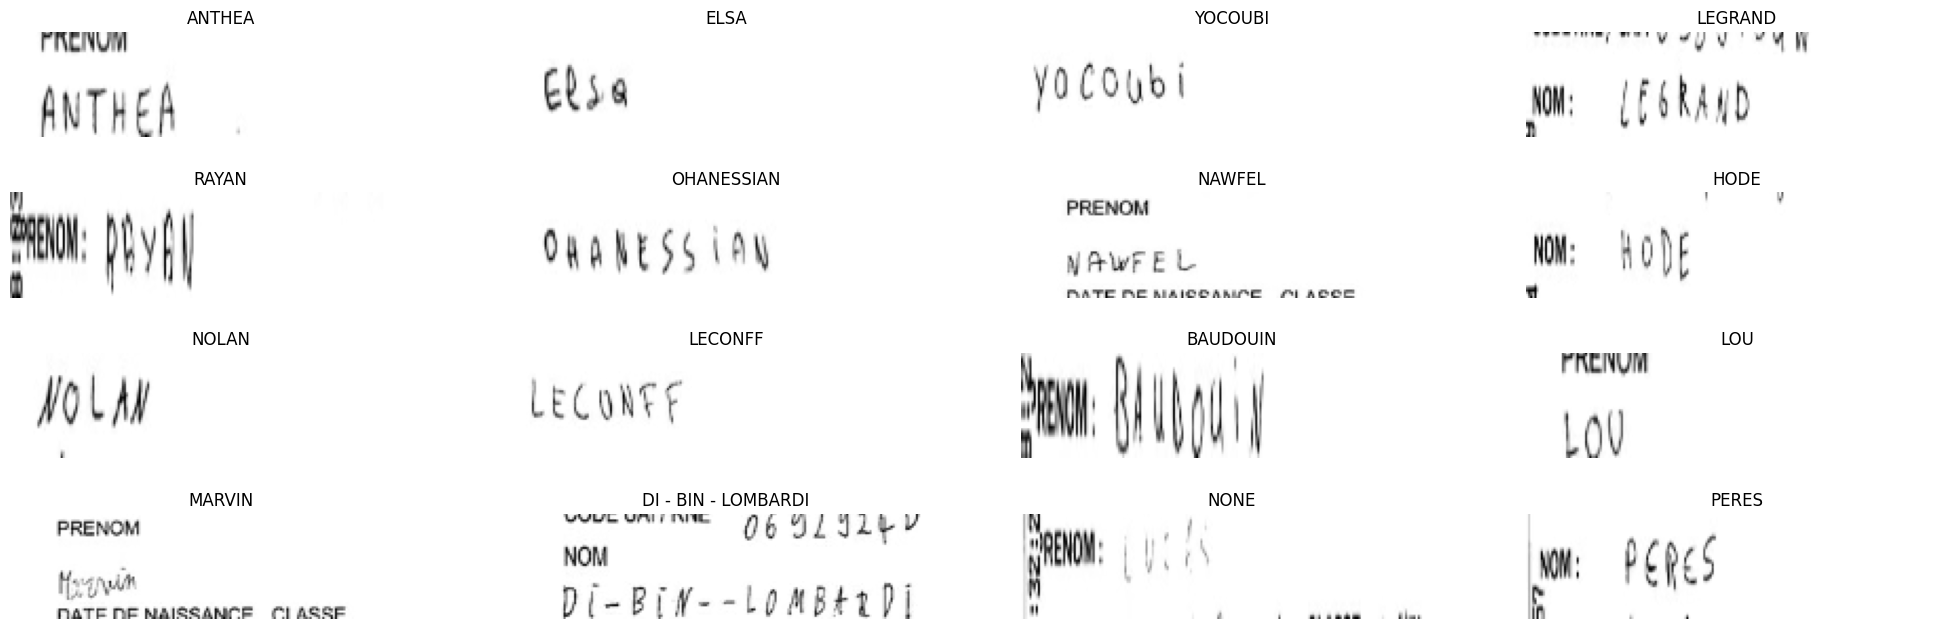

In [20]:
show_images(data=train_ds, cmap='gray')

#CTC Loss


In [21]:
class CTCLayer(Layer):
    def __init__(self, **kwargs) -> None:
        super().__init__(**kwargs)

        # define the loss function
        self.loss_function = tf.keras.backend.ctc_batch_cost

    def call(self, y_true, y_hat):
        # Get the batch length
        batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")

        # get the input and label lengths
        input_len = tf.cast(tf.shape(y_hat)[1], dtype='int64') * tf.ones(shape=(batch_len, 1), dtype='int64')
        label_len = tf.cast(tf.shape(y_true)[1], dtype='int64') * tf.ones(shape=(batch_len, 1), dtype='int64')

        # calculate the loss
        loss = self.loss_function(y_true, y_hat, input_len, label_len)

        self.add_loss(loss)

        return y_hat

# Model Creation


In [22]:
# Input Layer
input_images = Input(shape=(IMG_WIDTH, IMG_HEIGHT, 1), name="image")

# Labels : These are added for the training purpose.
input_labels = Input(shape=(None, ), name="label")

### Convolutional layers
# layer 1
conv_1 = Conv2D(64, 3, strides=1, padding="same", kernel_initializer="he_normal", activation="relu", name="conv_1")(input_images)
# layer 2
conv_2 = Conv2D(32, 3, strides=1, padding="same", kernel_initializer="he_normal", activation="relu", name="conv_2")(conv_1)
max_pool_1 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(conv_2)
# layer 3
conv_3 = Conv2D(64, 3, strides=1, padding='same', activation='relu', kernel_initializer='he_normal', name="conv_3")(max_pool_1)
conv_4 = Conv2D(32, 3, strides=1, padding='same', activation='relu', kernel_initializer='he_normal', name="conv_4")(conv_3)
max_pool_2 = MaxPool2D(pool_size=(2, 2), strides=(2, 2))(conv_4)



### Encoding
reshape = Reshape(target_shape=((IMG_WIDTH//4), (IMG_HEIGHT//4)*32), name="reshape_layer")(max_pool_2)
dense_encoding = Dense(64, kernel_initializer="he_normal", activation="relu", name="enconding_dense")(reshape)
dense_encoding_2 = Dense(64, kernel_initializer="he_normal", activation="relu", name="enconding_dense_2")(dense_encoding)
dropout = Dropout(0.4)(dense_encoding_2)

# Decoder
lstm_1 = Bidirectional(LSTM(128, return_sequences=True, dropout=0.25), name="bidirectional_lstm_1")(dropout)
lstm_2 = Bidirectional(LSTM(64, return_sequences=True, dropout=0.25), name="bidirectional_lstm_2")(lstm_1)

# Final Output layer
output = Dense(len(char_to_num.get_vocabulary())+1, activation="softmax", name="output_dense")(lstm_2)

# Add the CTC loss
ctc_loss_layer = CTCLayer()(input_labels, output)

# Define the final model
model = Model(inputs=[input_images, input_labels], outputs=[ctc_loss_layer])

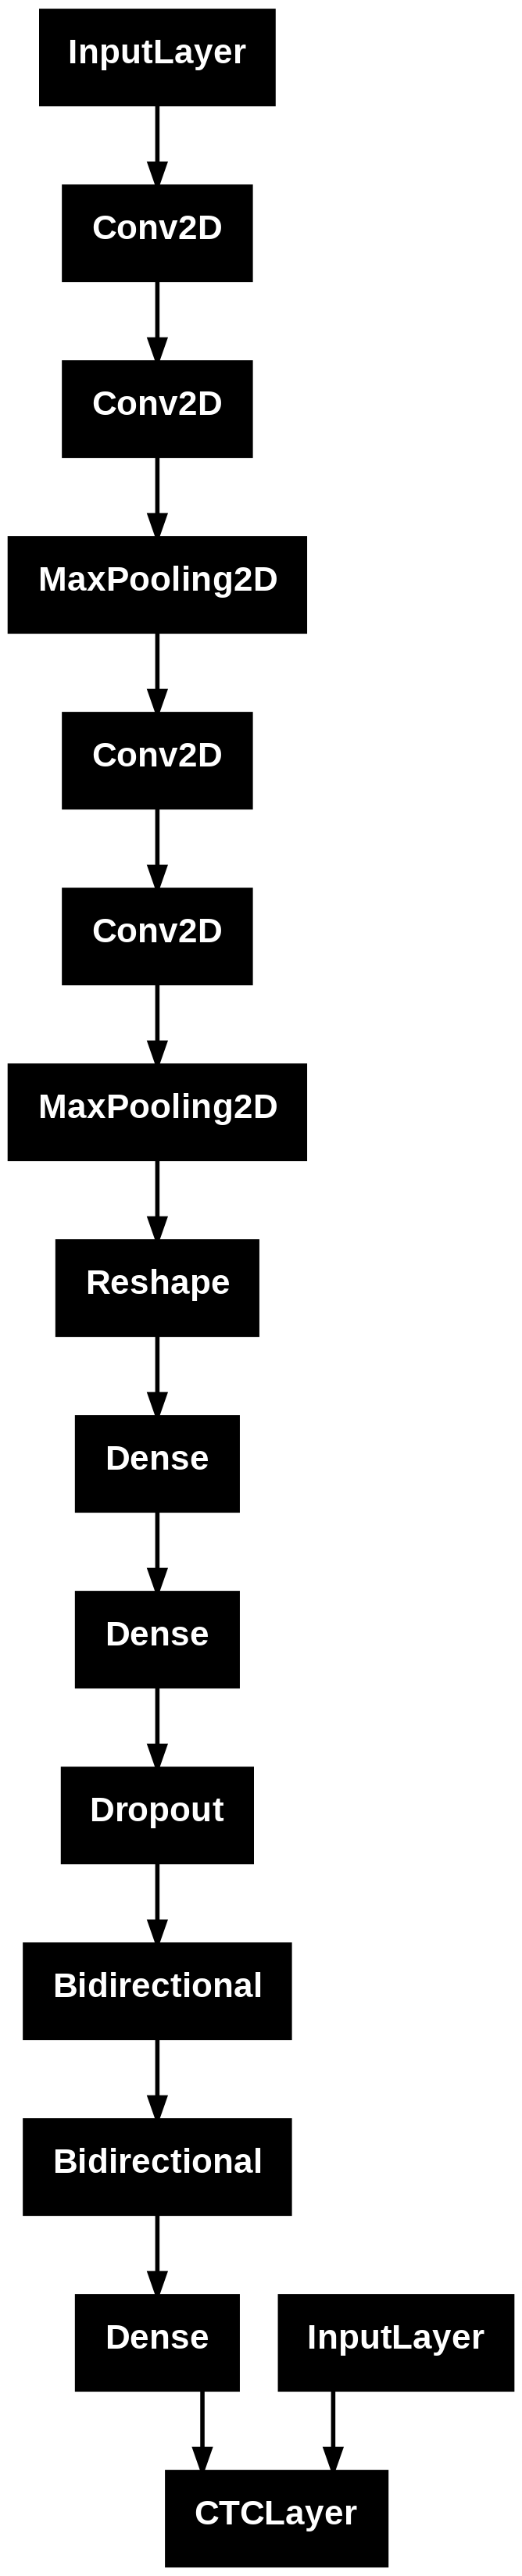

In [23]:
# draw the model plot
tf.keras.utils.plot_model(
    model,
    to_file='model-graph.png'
)

In [24]:
# see the model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)        │ (None, 200, 50, 1)     │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_1 (Conv2D)           │ (None, 200, 50, 64)    │            640 │ image[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_2 (Conv2D)           │ (None, 200, 50, 32)    │         18,464 │ conv_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 100, 25, 32)    │              0 │ conv_2[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_3 (Conv2D)           │ (None, 100, 25, 64)    │         18,496 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_4 (Conv2D)           │ (None, 100, 25, 32)    │         18,464 │ conv_3[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 50, 12, 32)     │              0 │ conv_4[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_layer (Reshape)   │ (None, 50, 384)        │              0 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ enconding_dense (Dense)   │ (None, 50, 64)         │         24,640 │ reshape_layer[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ enconding_dense_2 (Dense) │ (None, 50, 64)         │          4,160 │ enconding_dense[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 50, 64)         │              0 │ enconding_dense_2[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_lstm_1      │ (None, 50, 256)        │        197,632 │ dropout[0][0]          │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_lstm_2      │ (None, 50, 128)        │        164,352 │ bidirectional_lstm_1[… │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ label (InputLayer)        │ (None, None)           │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ output_dense (Dense)      │ (None, 50, 46)         │          5,934 │ bidirectional_lstm_2[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ ctc_layer (CTCLayer)      │ (None, 50, 46)         │              0 │ label[0][0],           │
│                           │                        │                │ output_dense[0][0]     │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 452,782 (1.73 MB)

 Trainable params: 452,782 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(optimizer="adam")

# Model Training

In [26]:
history = model.fit(train_ds, validation_data=valid_ds, epochs=EPOCHS, callbacks=CALLBACKS)

Epoch 1/50


I0000 00:00:1745126296.604942      59 cuda_dnn.cc:529] Loaded cuDNN version 90300


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 38ms/step - loss: 363.0364 - val_loss: 306.5099
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - loss: 305.1832 - val_loss: 298.0180
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - loss: 296.4924 - val_loss: 294.7198
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - loss: 293.8963 - val_loss: 293.2576
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - loss: 291.8308 - val_loss: 290.4545
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - loss: 287.3720 - val_loss: 272.2502
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - loss: 267.5699 - val_loss: 245.1149
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - loss: 239.0886 - val_loss: 210.4214
Epoch 9/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - loss: 202.2403 - val_loss: 176.0006
Epoch 10/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - loss: 174.5286 - val_loss: 161.5943
Epoch 11/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - loss: 156.5

# Results

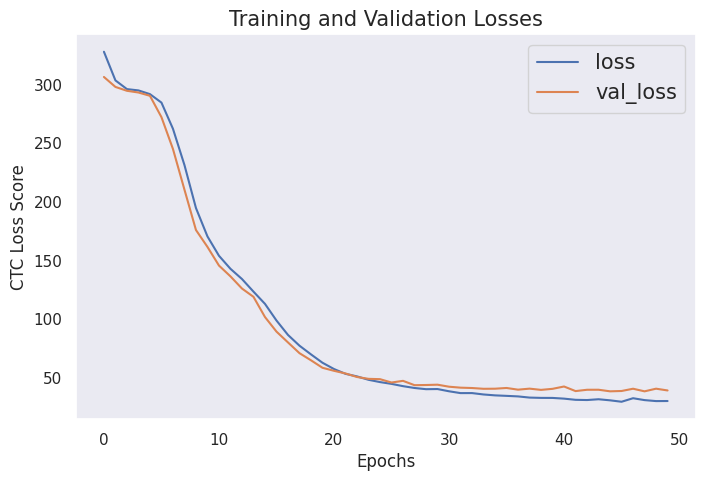

In [27]:
import seaborn as sb
sb.set()
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.legend(fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("CTC Loss Score")
plt.title("Training and Validation Losses", fontsize=15)
plt.grid()
plt.savefig("model_result.png")
plt.show()

In [28]:
# evaluate the model on the test dataset
evaluation = model.evaluate(test_ds)
print(f"evaluation loss: {evaluation}")

600/600 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 40.7125
evaluation loss: 42.09645462036133


In [29]:
# Define a model for testing and evaluation
pred_model = Model(inputs=input_images, outputs=output)


In [30]:
def decoder_prediction(pred_label):
    """
    This function has the job to decode the prediction that the model had.
    The model predicts each character and then this function makes it readable.
    """
    # Input length
    input_len = np.ones(shape=pred_label.shape[0]) * pred_label.shape[1]

    # CTC decode
    decode = tf.keras.backend.ctc_decode(pred_label, input_length=input_len, greedy=True)[0][0][:,:MAX_LABEL_LENGTH]

    # Converting numerics back to their character values
    chars = num_to_char(decode)

    # Join all the characters
    texts = [tf.strings.reduce_join(inputs=char).numpy().decode('UTF-8') for char in chars]

    # Remove the unknown token
    filtered_texts = [text.replace('[UNK]', " ").strip() for text in texts]

    return filtered_texts

# Testing

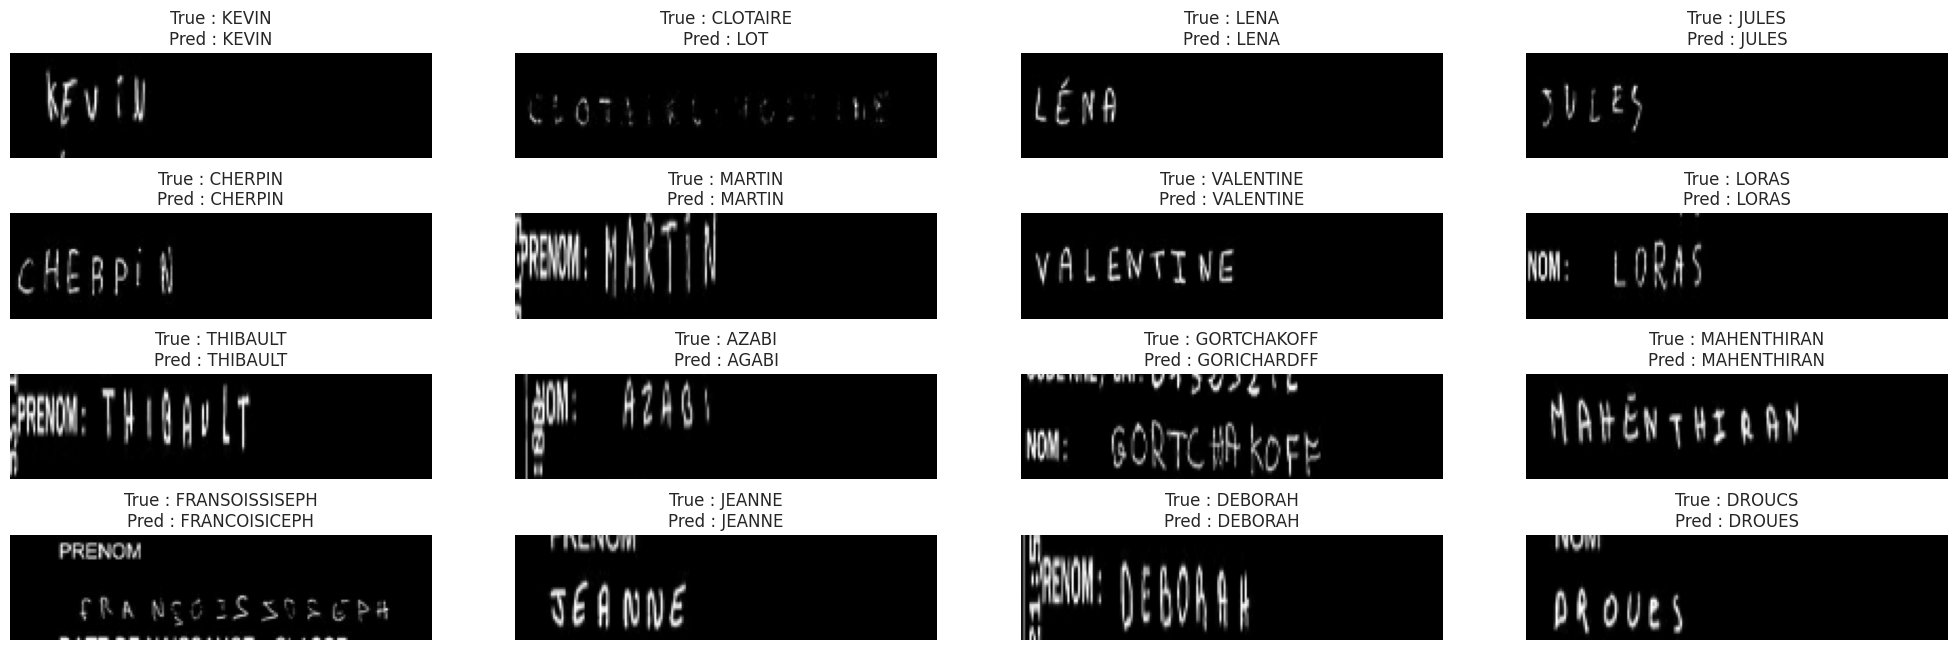

In [31]:
show_images(data=test_ds, model=pred_model, decode_pred=decoder_prediction, cmap='binary')

# Single Sample testing

In [32]:
def single_sample_prediction(model, path):
    """
    This function gets an image path and the model,
    Loads and preprocesses the image and make predictions on it.
    """
    # load image
    image_loading = tf.io.read_file(path)
    # decode image
    decoded_image = tf.image.decode_jpeg(contents=image_loading, channels=1)
    # convert the image data type to float
    convert_image = tf.image.convert_image_dtype(image=decoded_image, dtype=tf.float32)
    # resize the image
    resized_image = tf.image.resize(images=convert_image, size=(IMG_HEIGHT, IMG_WIDTH))
    resized_image = tf.transpose(resized_image, perm = [1, 0, 2])
    # convert image to array
    image_array = tf.cast(resized_image, dtype=tf.float32)
    # reshape image
    single_image_data_with_batch = np.expand_dims(image_array, axis=0)

    # make prediction
    prediction = decoder_prediction(model.predict(single_image_data_with_batch))

    return prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
['JULES']


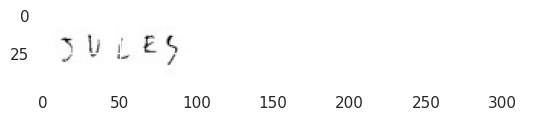

In [33]:
img_2_path = "/kaggle/input/handwriting-recognitionocr/test_v2/test/TEST_0004.jpg"
img_2 = implt.imread(img_2_path)
plt.imshow(img_2)
print(single_sample_prediction(pred_model, img_2_path))